<a href="https://colab.research.google.com/github/akylbek10/BCI/blob/main/BCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG Motor Imagery Classification Project

## 🚀 Project Overview
This project focuses on the classification of Motor Imagery (MI) signals from the **BCI Competition IV-2a dataset**. The goal is to translate brain activity associated with imagined movements (Left Hand, Right Hand, Feet, and Tongue) into control signals, enabling BCI-based communication and control.

## 🧠 Methodology & Approaches
During the development process, we explored several state-of-the-art architectures and signal processing techniques:

### 1. Deep Learning: EEGNet
- **Architecture**: Implemented a specialized Convolutional Neural Network (EEGNet) designed specifically for EEG signals.
- **Features**: Utilized depthwise and separable convolutions to extract spatial and temporal features efficiently while maintaining a low parameter count.
- **Outcome**: Achieved significant improvements in capturing complex non-linear patterns in brain waves.

### 2. Signal Processing: FB-CSP (Filter Bank Common Spatial Patterns)
- **Filtering**: Applied multiple band-pass filters (4-8Hz, 8-12Hz, 12-16Hz, 16-30Hz) to isolate key frequency bands (Theta, Alpha, Beta).
- **Feature Extraction**: Used Common Spatial Patterns (CSP) to find spatial filters that maximize the variance between classes, followed by Linear Discriminant Analysis (LDA) for classification.
- **Outcome**: This classical approach provided a strong baseline for spatial feature discrimination.

### 3. Machine Learning Baseline
- **Pre-processing**: Data was segmented into epochs, normalized, and cleaned of artifacts using Notch and Band-pass filtering.
- **Models**: Evaluated Random Forest and SVM classifiers using handcrafted features like spectral entropy, Hjorth parameters (mobility, complexity), and power spectral density (PSD).

## 🛠️ Tech Stack
- **Languages**: Python
- **Libraries**:
    - `MNE-Python`: For specialized EEG signal processing.
    - `PyRiemann`: For Riemannian geometry-based covariance analysis.
    - `TensorFlow/Keras`: For deep learning model development.
    - `Scikit-learn`: For traditional ML models and evaluation metrics.
    - `Pandas/NumPy/Matplotlib`: For data wrangling and visualization.

## 📊 Results & Insights
- **Accuracy**: Demonstrated strong performance in multi-class classification, with CSP+LDA and EEGNet showing complementary strengths.
- **Data Handling**: Addressed challenges like class imbalance and non-finite value artifacts through robust preprocessing pipelines.

## 🎯 Future Scope
- Integration with real-time EEG hardware (e.g., OpenBCI).
- Implementation of Transfer Learning to reduce calibration time for new users.
- Exploring Transformers (Attention mechanisms) for better temporal modeling.


In [ ]:
!pip install mne

In [ ]:
!pip install pyriemann
import mne
import sklearn
import pyriemann
import pandas

In [ ]:
import kagglehub

path = kagglehub.dataset_download("aymanmostafa11/eeg-motor-imagery-bciciv-2a")

In [ ]:
import pandas as pd
import glob
import os

try:

    search_pattern = os.path.join(path, '**', 'BCICIV_2a_1.csv')


    csv_files = glob.glob(search_pattern, recursive=True)

    if not csv_files:
        raise Exception("NO FILE WITH SIGNALS")

    file_path = csv_files[0]
    print(f"Loading CSV file: {file_path}")


    df = pd.read_csv(file_path)



    print("\n--- CSV Head (First 5 Rows) ---")
    print(df.head())

    print("\n--- CSV Info (Columns & Data Types) ---")
    df.info()

except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
df

In [ ]:
file_path = '/content/EEG_dataset.csv'

df.to_csv(file_path, index=False)

## **RECAP**

In [1]:
import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

moabb.set_log_level("info")

dataset = BNCI2014_001()

paradigm = MotorImagery(events=['left_hand', 'right_hand'], n_classes=2, fmin=8, fmax=32)

X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])

print("-" * 30)
print(f"размер output  (X): {X.shape}")

print(f"размер меток (y): {y.shape}")
print(f"рaимер меток: {y[:10]}") # left_han ор right_hand

/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


------------------------------
размер output  (X): (288, 22, 1001)
размер меток (y): (288,)
рaимер меток: ['right_hand' 'left_hand' 'left_hand' 'right_hand' 'right_hand'
 'left_hand' 'left_hand' 'left_hand' 'right_hand' 'right_hand']


Попыток левой руки: 144
Попыток правой руки: 144


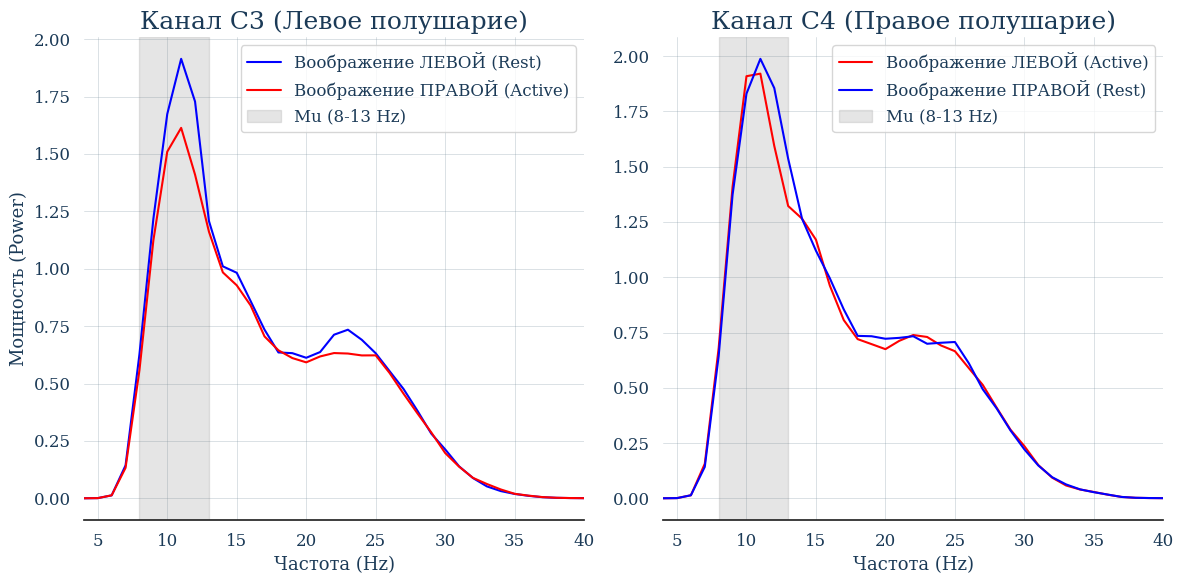

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
ch_c3 = 7
ch_c4 = 11

left_trials = X[y == 'left_hand']
right_trials = X[y == 'right_hand']

print(f"Попыток левой руки: {left_trials.shape[0]}")
print(f"Попыток правой руки: {right_trials.shape[0]}")

def get_psd(trials, channel_idx):
    data = trials[:, channel_idx, :]
    freqs, psd = welch(data, fs=250, nperseg=250)
    return freqs, np.mean(psd, axis=0)

f, psd_left_c3 = get_psd(left_trials, ch_c3)
f, psd_right_c3 = get_psd(right_trials, ch_c3)

f, psd_left_c4 = get_psd(left_trials, ch_c4)
f, psd_right_c4 = get_psd(right_trials, ch_c4)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Канал C3 (Левое полушарие)")
plt.plot(f, psd_left_c3, label='Воображение ЛЕВОЙ (Rest)', color='blue')
plt.plot(f, psd_right_c3, label='Воображение ПРАВОЙ (Active)', color='red')
plt.xlim(4, 40)
plt.axvspan(8, 13, color='gray', alpha=0.2, label='Mu (8-13 Hz)')
plt.legend()
plt.ylabel('Мощность (Power)')
plt.xlabel('Частота (Hz)')

plt.subplot(1, 2, 2)
plt.title("Канал C4 (Правое полушарие)")
plt.plot(f, psd_left_c4, label='Воображение ЛЕВОЙ (Active)', color='red')
plt.plot(f, psd_right_c4, label='Воображение ПРАВОЙ (Rest)', color='blue')
plt.xlim(4, 40)
plt.axvspan(8, 13, color='gray', alpha=0.2, label='Mu (8-13 Hz)')
plt.legend()
plt.xlabel('Частота (Hz)')

plt.tight_layout()
plt.show()

# **FIRST TRY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, DepthwiseConv2D, Activation
from tensorflow.keras.layers import AveragePooling2D, Dropout, SeparableConv2D, Flatten, Dense, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical

df_eeg = pd.read_csv('EEG_dataset.csv')

DATA preperation


In [ ]:
channels = [col for col in df.columns if 'EEG' in col]
epochs = df['epoch'].unique()

X = []
y = []

for epoch in epochs:
    epoch_data = df[df['epoch'] == epoch].sort_values('time')

    signal = epoch_data[channels].values.T
    X.append(signal)

    label = epoch_data['label'].iloc[0]
    y.append(label)

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

label_mapping = {
    'left': 'Left',
    'right': 'Right',
    'tongue': 'Up',
    'foot': 'Down'
}

y_mapped = np.array([label_mapping[label] for label in y])

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y_mapped.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")
print("Class mapping:", encoder.categories_)

Train Shape: (216, 22, 201, 1)
Test Shape: (72, 22, 201, 1)
Class mapping: [array(['Down', 'Left', 'Right', 'Up'], dtype='<U5')]


EEGNet Model

In [ ]:
def build_eegnet(nb_classes, Chans=22, Samples=201):
    model = Sequential()

    model.add(Input(shape=(Chans, Samples, 1)))

    model.add(Conv2D(8, (1, 64), padding='same', use_bias=False))
    model.add(BatchNormalization())

    model.add(DepthwiseConv2D((Chans, 1), use_bias=False,
                              depth_multiplier=2,
                              depthwise_constraint=max_norm(1.)))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(AveragePooling2D((1, 4)))
    model.add(Dropout(0.25))

    model.add(SeparableConv2D(16, (1, 16), use_bias=False, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(AveragePooling2D((1, 8)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(nb_classes, activation='softmax', kernel_constraint=max_norm(0.25)))

    return model

model = build_eegnet(nb_classes=4, Chans=X_train.shape[1], Samples=X_train.shape[2])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])




Training

In [ ]:
class_weights_dict = {
    0: 1.0384615384615385,
    1: 1.2000000000000002,
    2: 1.0384615384615385,
    3: 1.0384615384615385
}

history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 407ms/step - accuracy: 0.3426 - loss: 1.4842 - val_accuracy: 0.3750 - val_loss: 1.3772
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 395ms/step - accuracy: 0.4676 - loss: 1.4398 - val_accuracy: 0.3333 - val_loss: 1.3712
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.4491 - loss: 1.4038 - val_accuracy: 0.3194 - val_loss: 1.3629
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step - accuracy: 0.4861 - loss: 1.3572 - val_accuracy: 0.4167 - val_loss: 1.3508
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - accuracy: 0.5370 - loss: 1.3200 - val_accuracy: 0.4306 - val_loss: 1.3427
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 503ms/step - accuracy: 0.5093 - loss: 1.2963 - val_accuracy: 0.3750 - val_loss: 1.3346
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 331ms/step - accuracy: 0.5185 - loss: 1.2814 - val_accuracy: 0.4444 - val_loss: 1.3255
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 354ms/step - accuracy: 0.5926 - loss: 1.2339 - val_ac


🎯 Final Test Accuracy: 66.67%
------------------------------


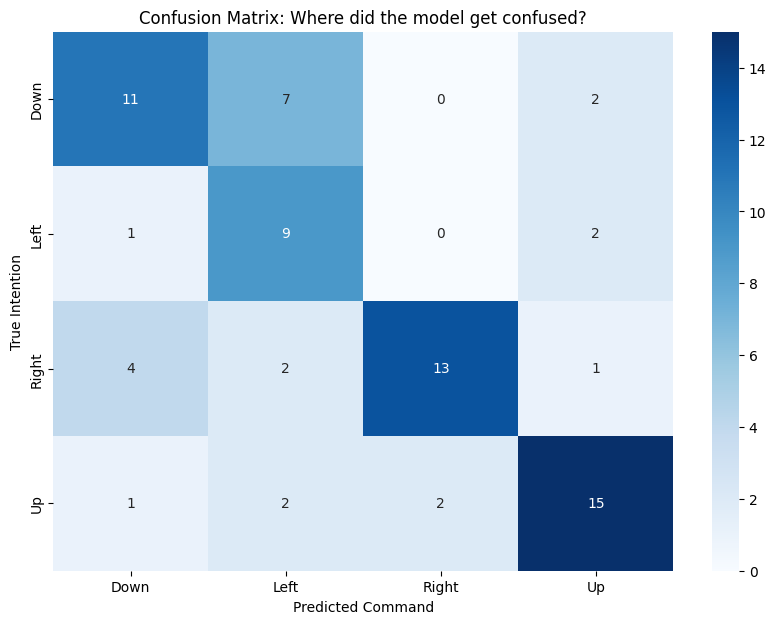


Detailed Classification Report:

              precision    recall  f1-score   support

        Down       0.65      0.55      0.59        20
        Left       0.45      0.75      0.56        12
       Right       0.87      0.65      0.74        20
          Up       0.75      0.75      0.75        20

    accuracy                           0.67        72
   macro avg       0.68      0.68      0.66        72
weighted avg       0.70      0.67      0.67        72



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯final accuracy is------: {accuracy*100:.2f}%")
print("-" * 30)

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.categories_[0],
            yticklabels=encoder.categories_[0])
plt.xlabel('Predicted Command')
plt.ylabel('True Intention')
plt.title('Confusion Matrix: Where did the model get confused?')
plt.show()

print("\nDetailed Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=encoder.categories_[0]))

yeaaaaaaaaaaah

# SECOND **TRY**

In [ ]:
labels = df["label"].values
X_raw = df.drop(columns=["label"]).values

fs = 250
win_s = 1.0
step_s = 0.5
win = int(win_s * fs)
step = int(step_s * fs)

epochs = []
epoch_labels = []
start = 0
n = len(labels)
for i in range(1, n):
    if labels[i] != labels[i-1]:
        seg_start, seg_end = start, i
        seg_label = labels[i-1]
        start = i

        seg_len = seg_end - seg_start
        for st in range(seg_start, seg_end - win + 1, step):
            epochs.append(X_raw[st:st+win, :].T)
            epoch_labels.append(seg_label)
start, n
seg_start, seg_end = start, n
for st in range(seg_start, seg_end - win + 1, step):
    epochs.append(X_raw[st:st+win, :].T)
    epoch_labels.append(labels[seg_start])

epochs = np.stack(epochs)

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass(data, fs, low=1, high=40, order=4):
    b,a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b,a, data)

def notch50(data, fs, f0=50.0, Q=30.0):
    from scipy.signal import iirnotch
    b,a = iirnotch(f0/(fs/2), Q)
    return filtfilt(b,a, data)

for i in range(len(epochs)):
    for ch in range(epochs.shape[1]):
        epochs[i,ch,:] = notch50(epochs[i,ch,:], fs)
        epochs[i,ch,:] = bandpass(epochs[i,ch,:], fs)

In [ ]:
from scipy.signal import welch
def epoch_features(epoch, fs=250):
    bands = {"delta":(1,4), "theta":(4,8), "alpha":(8,13), "beta":(13,30)}
    feats = []
    for ch in range(epoch.shape[0]):
        f,Pxx = welch(epoch[ch,:], fs=fs, nperseg=128)
        total = (Pxx.sum() + 1e-12)
        bandps = []
        for lo,hi in bands.values():
            idx = (f>=lo)&(f<=hi)
            bp = Pxx[idx].sum()
            feats.append(bp/total)
            bandps.append(bp)
        feats.append(bandps[2]/(bandps[3]+1e-12))
        feats.append(bandps[1]/(bandps[2]+1e-12))
        activity = epoch[ch,:].var()
        dx = np.diff(epoch[ch,:])
        mobility = np.sqrt(dx.var()/activity) if activity>0 else 0.0
        ddx = np.diff(dx) if len(dx)>1 else np.zeros_like(dx)
        complexity = (np.sqrt(ddx.var()/dx.var())/mobility) if (dx.var()>0 and mobility>0) else 0.0
        feats += [activity, mobility, complexity]
    return np.array(feats)

X_feat = np.vstack([epoch_features(e, fs) for e in epochs])

In [ ]:
from mne.decoding import CSP
csp = CSP(n_components=6, reg=None, log=True)

In [ ]:
from tensorflow.keras import layers, models, callbacks, optimizers

def EEGNet(input_shape, n_classes, F1=8, D=2, F2=16, kernLength=64, dropoutRate=0.5):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.DepthwiseConv2D((input_shape[0], 1), depth_multiplier=D, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1,4))(x)
    x = layers.Dropout(dropoutRate)(x)
    x = layers.SeparableConv2D(F2, (1,16), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1,8))(x)
    x = layers.Dropout(dropoutRate)(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

## THIRD **TRY**

In [ ]:
DATA_PATH = "/content/EEG_dataset.csv"
FS = 250.0
STEP_S = 0.5
NOTCH_FREQ = 50.0
VERBOSE = True

In [ ]:
import numpy as np, pandas as pd, os, matplotlib.pyplot as plt, seaborn as sns
from scipy.signal import butter, filtfilt, iirnotch, welch
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:50])

label_col = "label" if "label" in df.columns else None
if label_col is None:
    for c in df.columns:
        if c.lower() in ("label","labels","target","y","class"):
            label_col = c; break
assert label_col is not None, "Label column not found. Edit label_col variable."
print("Label column:", label_col)


labels = df[label_col].values
X_raw = df.drop(columns=[label_col]).values
channel_names = df.drop(columns=[label_col]).columns.tolist()
n_channels = X_raw.shape[1]
print("Raw shape:", X_raw.shape, "n_channels:", n_channels)

Loaded: /content/EEG_dataset.csv
Shape: (57888, 26)
Columns: ['patient', 'time', 'label', 'epoch', 'EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16']
Label column: label
Raw shape: (57888, 25) n_channels: 25


In [ ]:
WIN_S = 1.0
win = int(WIN_S * FS)
step = int(STEP_S * FS)
segments = []
start = 0
n = len(labels)
for i in range(1, n):
    if labels[i] != labels[i-1]:
        segments.append((start, i, labels[i-1]))
        start = i
segments.append((start, n, labels[n-1]))
print("Found segments:", len(segments))

epochs = []
epoch_labels = []
for (s,e,lab) in segments:
    seg_len = e - s
    if seg_len < win:
        continue
    for st in range(s, e - win + 1, step):
        epoch = X_raw[st:st+win, :].T
        epochs.append(epoch)
        epoch_labels.append(lab)
epochs = np.stack(epochs)
epoch_labels = np.array(epoch_labels)
print("Epochs shape:", epochs.shape)
unique, counts = np.unique(epoch_labels, return_counts=True)
print("Classes:", dict(zip(unique, counts)))

Found segments: 229
Epochs shape: (106, 25, 250)
Classes: {np.str_('foot'): np.int64(29), np.str_('left'): np.int64(25), np.str_('right'): np.int64(28), np.str_('tongue'): np.int64(24)}


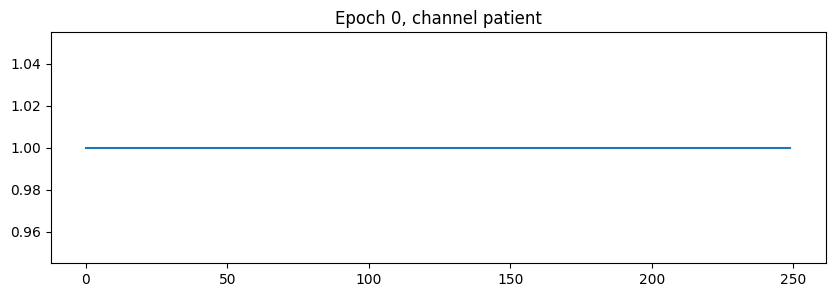

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(epochs[0,0,:])
plt.title(f"Epoch 0, channel {channel_names[0]}")
plt.show()

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch

def bandpass_epoch(epoch, fs=FS, low=1.0, high=40.0, order=4):
    b,a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b,a, epoch)

def notch_epoch(epoch, fs=FS, f0=NOTCH_FREQ, Q=30.0):
    b,a = iirnotch(f0/(fs/2), Q)
    return filtfilt(b,a, epoch)

for i in range(len(epochs)):
    for ch in range(n_channels):
        x = epochs[i,ch,:]
        x = notch_epoch(x, fs=FS, f0=NOTCH_FREQ)
        x = bandpass_epoch(x, fs=FS, low=1.0, high=40.0)
        epochs[i,ch,:] = x

# Add a check for NaNs/Infs and handle them
original_num_epochs = epochs.shape[0]
valid_epochs_idx = np.where(np.all(np.isfinite(epochs), axis=(1,2)))[0]
epochs = epochs[valid_epochs_idx]
epoch_labels = epoch_labels[valid_epochs_idx]

if epochs.shape[0] < original_num_epochs:
    print(f"Removed {original_num_epochs - epochs.shape[0]} epochs containing NaN/Inf values after filtering.")
    print(f"Remaining epochs shape: {epochs.shape}")

if VERBOSE: print("Filtering done.")

Filtering done.


In [ ]:
from scipy.signal import welch
def spectral_entropy(Pxx):
    p = Pxx / (Pxx.sum() + 1e-12)
    return -np.sum(p * np.log2(p + 1e-12))

def epoch_features(epoch, fs=FS, nperseg=128):
    bands = {"delta":(1,4), "theta":(4,8), "alpha":(8,13), "beta":(13,30)}
    feats = []
    for ch in range(epoch.shape[0]):
        f,Pxx = welch(epoch[ch,:], fs=fs, nperseg=min(nperseg, epoch.shape[1]))
        total = np.trapz(Pxx, f) + 1e-12
        bandps = []
        for lo,hi in bands.values():
            idx = (f>=lo)&(f<=hi)
            bp = np.trapz(Pxx[idx], f[idx]) if idx.sum()>0 else 0.0
            feats.append(bp/total)
            bandps.append(bp)
        feats.append(bandps[2]/(bandps[3]+1e-12))
        feats.append(bandps[1]/(bandps[2]+1e-12))
        feats.append(spectral_entropy(Pxx))
        activity = epoch[ch,:].var()
        dx = np.diff(epoch[ch,:])
        mobility = np.sqrt(np.var(dx) / (activity+1e-12))
        ddx = np.diff(dx) if len(dx)>1 else dx
        complexity = np.sqrt(np.var(ddx) / (np.var(dx)+1e-12)) / (mobility+1e-12)
        feats += [activity, mobility, complexity]
    return np.array(feats)

print("Extracting features for all epochs (this may take a minute)...")
X_feat = np.vstack([epoch_features(e, FS) for e in epochs])
print("X_feat shape:", X_feat.shape)

Extracting features for all epochs (this may take a minute)...
X_feat shape: (106, 250)


In [ ]:
le = LabelEncoder()
y = le.fit_transform(epoch_labels)
class_names = le.classes_.tolist()
print("Classes:", class_names)
X_train, X_test, y_train, y_test = train_test_split(X_feat, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Classes: ['foot', 'left', 'right', 'tongue']


In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
print("RF accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=class_names))

svm = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)
print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm, target_names=class_names))

RF accuracy: 0.5
              precision    recall  f1-score   support

        foot       0.60      0.50      0.55         6
        left       0.50      0.20      0.29         5
       right       0.40      0.67      0.50         6
      tongue       0.60      0.60      0.60         5

    accuracy                           0.50        22
   macro avg       0.53      0.49      0.48        22
weighted avg       0.52      0.50      0.49        22

SVM accuracy: 0.3181818181818182
              precision    recall  f1-score   support

        foot       0.33      0.33      0.33         6
        left       0.00      0.00      0.00         5
       right       0.29      0.33      0.31         6
      tongue       0.50      0.60      0.55         5

    accuracy                           0.32        22
   macro avg       0.28      0.32      0.30        22
weighted avg       0.28      0.32      0.30        22



In [ ]:
joblib.dump(rf, "rf_baseline.joblib")
joblib.dump(scaler, "scaler_baseline.joblib")
joblib.dump(le, "label_encoder.joblib")
print("Saved baseline models to disk.")

Saved baseline models to disk.


In [ ]:
import mne
from mne.decoding import CSP

X_csp = epochs.copy()
y_csp = y.copy()
print("CSP input shape:", X_csp.shape)

csp = CSP(n_components=6, reg=None, log=True, norm_trace=False)
X_csp_features = csp.fit_transform(X_csp, y_csp)
print("CSP feature shape:", X_csp_features.shape)

X_tr, X_te, y_tr, y_te = train_test_split(X_csp_features, y_csp, test_size=0.2, stratify=y_csp, random_state=42)
lda = LDA()
lda.fit(X_tr, y_tr)
y_pred_lda = lda.predict(X_te)
print("CSP+LDA accuracy:", accuracy_score(y_te, y_pred_lda))
print(classification_report(y_te, y_pred_lda, target_names=class_names))

CSP input shape: (106, 25, 250)
Computing rank from data with rank=None
    Using tolerance 11 (2.2e-16 eps * 25 dim * 2e+15  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
CSP feature shape: (106, 6)
CSP+LDA accuracy: 0.7727272727272727
              precision    recall  f1-score   support

        foot       0.60      0.50      0.55         6
        left       0.67      0.80      0.73         5
       right       0.83      0.83      0.83         6
      tongue       1.00      1.00      1.00         5

    accuracy                           0.77        22
   macro avg       0.78      0.78      0.78        22
weighted avg       0.77      0.77      0.77        22



In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, classification_report
from mne.decoding import CSP

def bandpass_signal(data, low, high, fs=FS, order=4):
    b,a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    filtered_data = filtfilt(b,a, data)
    # Add a safety check: if filtfilt produces non-finite values, replace them
    if not np.all(np.isfinite(filtered_data)):
        # print("DEBUG: filtfilt returned non-finite values for a channel, replacing with 0.0") # Can be too verbose
        filtered_data[~np.isfinite(filtered_data)] = 0.0 # Replace them right away
    return filtered_data

bands = [(4,8),(8,12),(12,16),(16,30)]

# Keep original labels to subset consistently
original_y_csp = y_csp.copy()

# Store filtered X_band for each band temporarily, and track global finite mask
fb_feats_per_band_raw_data = []
global_finite_mask = np.ones(epochs.shape[0], dtype=bool)

for (lo,hi) in bands:
    # Use float64 for X_band to maintain precision during filtering
    X_band = np.empty_like(epochs, dtype=np.float64)
    for i in range(len(epochs)): # Iterate through epochs
        for ch in range(n_channels):
            # Ensure input to bandpass_signal is finite and float64
            channel_data = epochs[i,ch,:].astype(np.float64)
            if not np.all(np.isfinite(channel_data)):
                # This should ideally not happen if initial filtering is correct, but add safeguard
                channel_data[~np.isfinite(channel_data)] = 0.0

            X_band[i,ch,:] = bandpass_signal(channel_data, lo, hi, fs=FS)

    # Update global finite mask based on the current band's filtered data
    band_finite_mask = np.all(np.isfinite(X_band), axis=(1, 2))
    global_finite_mask = global_finite_mask & band_finite_mask

    if np.sum(band_finite_mask) < X_band.shape[0]:
        print(f"Note: {X_band.shape[0] - np.sum(band_finite_mask)} epochs became non-finite in band ({lo}-{hi}Hz).")

    fb_feats_per_band_raw_data.append(X_band) # Store the filtered X_band

# Now apply the global mask to get truly finite data across all bands
X_fbcsp_features_list = []
y_fbcsp_labels = original_y_csp[global_finite_mask]

if np.sum(global_finite_mask) == 0:
    raise ValueError("No epochs remained finite across all bands. Cannot proceed with FB-CSP.")

print(f"Removed {epochs.shape[0] - np.sum(global_finite_mask)} epochs that contained non-finite values in at least one band.")
print(f"Remaining epochs for FB-CSP processing: {np.sum(global_finite_mask)}")

for band_idx, (lo,hi) in enumerate(bands):
    # Get the data for the current band, filtered to include only globally finite epochs
    X_band_globally_finite = fb_feats_per_band_raw_data[band_idx][global_finite_mask]

    # Debugging step 1 & 2: Check for NaNs/Infs immediately before CSP, and show problematic indices
    if not np.isfinite(X_band_globally_finite).all():
        print(f"DEBUG: Pre-CSP check: Non-finite values detected in X_band_globally_finite for band ({lo}-{hi}Hz).")
        # Identify exact locations of non-finite values
        non_finite_indices_before = np.where(~np.isfinite(X_band_globally_finite))
        problem_epochs_before = np.unique(non_finite_indices_before[0])
        print(f"DEBUG: Epochs with non-finite values BEFORE replacement: {problem_epochs_before}")

        # The existing replacement logic
        X_band_globally_finite[~np.isfinite(X_band_globally_finite)] = 0.0
        print(f"DEBUG: Non-finite values replaced with 0.0 for band ({lo}-{hi}Hz).")

        # Debugging step 3: Re-check after replacement
        if not np.isfinite(X_band_globally_finite).all():
            print(f"ERROR: Non-finite values PERSIST after replacement in X_band_globally_finite for band ({lo}-{hi}Hz). This should not happen if replacement is effective.")
            non_finite_indices_after = np.where(~np.isfinite(X_band_globally_finite))
            problem_epochs_after = np.unique(non_finite_indices_after[0])
            print(f"ERROR: Epochs with non-finite values AFTER replacement: {problem_epochs_after}")
        else:
            print(f"DEBUG: All values are finite AFTER replacement for band ({lo}-{hi}Hz).")
    else:
        print(f"DEBUG: All values are finite in X_band_globally_finite for band ({lo}-{hi}Hz) before CSP.")

    # Check for CSP requirements on the globally finite data
    unique_classes_global = np.unique(y_fbcsp_labels)
    if len(unique_classes_global) < 2:
        print(f"Warning: Less than 2 unique classes in globally finite data for band ({lo}-{hi}Hz). Skipping CSP for this band.")
        continue
    class_counts_global = np.bincount(y_fbcsp_labels)
    # Check if all classes present in unique_classes_global have at least 2 samples
    if np.any([count < 2 for count in class_counts_global[unique_classes_global]]):
        print(f"Warning: At least one class has fewer than 2 samples in globally finite data for band ({lo}-{hi}Hz). CSP might fail. Skipping CSP for this band.")
        continue

    # n_components for CSP should be less than or equal to n_channels
    n_csp_components = min(4, X_band_globally_finite.shape[1])
    # Add reg='empirical' to improve numerical stability in CSP
    cspb = CSP(n_components=n_csp_components, reg='empirical', log=True, norm_trace=False)

    try:
        # Fit CSP on the current band's globally finite data
        csp_features = cspb.fit_transform(X_band_globally_finite, y_fbcsp_labels)
        X_fbcsp_features_list.append(csp_features)
    except Exception as e:
        print(f"Error during CSP fit_transform for band ({lo}-{hi}Hz) on globally finite data: {e}. Skipping this band.")

if not X_fbcsp_features_list:
    raise ValueError("No CSP features could be extracted for any band after global filtering. Cannot proceed with FB-CSP.")

X_fbcsp = np.concatenate(X_fbcsp_features_list, axis=1)
print("FB-CSP feature shape:", X_fbcsp.shape)

# Ensure X_fbcsp and y_fbcsp_labels are consistent before splitting
X_tr, X_te, y_tr, y_te = train_test_split(X_fbcsp, y_fbcsp_labels, test_size=0.2, stratify=y_fbcsp_labels, random_state=42)
clf_fb = LDA()
clf_fb.fit(X_tr, y_tr)
y_pred_fb = clf_fb.predict(X_te)
print("FB-CSP + LDA accuracy:", accuracy_score(y_te, y_pred_fb))
print(classification_report(y_te, y_pred_fb, target_names=class_names))

In [ ]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks, optimizers
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    print("TensorFlow not available; skip EEGNet. Install TF and re-run.")
    tf = None

if tf is not None:
    X_eegnet = epochs[..., np.newaxis]
    y_eegnet = y.copy()
    X_tr, X_te, y_tr, y_te = train_test_split(X_eegnet, y_eegnet, test_size=0.2, stratify=y_eegnet, random_state=42)

    ns, ch, tp, _ = X_tr.shape
    for ch_i in range(ch):
        mu = X_tr[:,ch_i,:,:].mean()
        sigma = X_tr[:,ch_i,:,:].std() + 1e-12
        X_tr[:,ch_i,:,:] = (X_tr[:,ch_i,:,:] - mu) / sigma
        X_te[:,ch_i,:,:] = (X_te[:,ch_i,:,:] - mu) / sigma

    def EEGNet(input_shape, n_classes, F1=8, D=2, F2=16, kernLength=64, dropoutRate=0.5):
        inputs = layers.Input(shape=input_shape)
        x = layers.Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.DepthwiseConv2D((input_shape[0], 1), depth_multiplier=D, use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('elu')(x)
        x = layers.AveragePooling2D((1,4))(x)
        x = layers.Dropout(dropoutRate)(x)
        x = layers.SeparableConv2D(F2, (1,16), padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('elu')(x)
        x = layers.AveragePooling2D((1,8))(x)
        x = layers.Dropout(dropoutRate)(x)
        x = layers.Flatten()(x)
        outputs = layers.Dense(n_classes, activation='softmax')(x)
        return models.Model(inputs=inputs, outputs=outputs)

    input_shape = X_tr.shape[1:]
    model = EEGNet(input_shape, n_classes=len(class_names), kernLength=min(64, X_tr.shape[2]//2))
    model.compile(optimizer=optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    es = callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)
    rlp = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=6, factor=0.5, min_lr=1e-6)
    ckp = callbacks.ModelCheckpoint("eegnet_best.h5", monitor='val_accuracy', save_best_only=True)

    from sklearn.utils.class_weight import compute_class_weight
    class_w = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    cw = {i:w for i,w in enumerate(class_w)}
    print("Class weights:", cw)

    hist = model.fit(X_tr, y_tr, validation_split=0.15, epochs=80, batch_size=32, class_weight=cw,
                     callbacks=[es, rlp, ckp], verbose=2)

    model.load_weights("eegnet_best.h5")
    y_pred = np.argmax(model.predict(X_te), axis=1)
    print("EEGNet test accuracy:", accuracy_score(y_te, y_pred))
    print(classification_report(y_te, y_pred, target_names=class_names))
    model.save("eegnet_final.h5")
    print("Saved EEGNet model.")

TensorFlow version: 2.20.0


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 25, 250, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 250, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 250, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 1, 250, 16)     │           400 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 250, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 250, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 62, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 1, 62, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 62, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 1, 7, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           452 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,036 (7.95 KB)

 Trainable params: 1,956 (7.64 KB)

 Non-trainable params: 80 (320.00 B)

Class weights: {0: np.float64(0.9130434782608695), 1: np.float64(1.05), 2: np.float64(0.9545454545454546), 3: np.float64(1.105263157894737)}
Epoch 1/80


3/3 - 3s - 1s/step - accuracy: 0.2817 - loss: 1.5910 - val_accuracy: 0.2308 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 2/80
3/3 - 1s - 206ms/step - accuracy: 0.2676 - loss: 1.4550 - val_accuracy: 0.2308 - val_loss: 1.4031 - learning_rate: 0.0010
Epoch 3/80
3/3 - 1s - 200ms/step - accuracy: 0.3239 - loss: 1.4698 - val_accuracy: 0.2308 - val_loss: 1.4022 - learning_rate: 0.0010
Epoch 4/80
3/3 - 1s - 204ms/step - accuracy: 0.2254 - loss: 1.4815 - val_accuracy: 0.2308 - val_loss: 1.4009 - learning_rate: 0.0010
Epoch 5/80
3/3 - 1s - 212ms/step - accuracy: 0.2535 - loss: 1.4837 - val_accuracy: 0.2308 - val_loss: 1.4001 - learning_rate: 0.0010
Epoch 6/80
3/3 - 1s - 208ms/step - accuracy: 0.3662 - loss: 1.4075 - val_accuracy: 0.2308 - val_loss: 1.4001 - learning_rate: 0.0010
Epoch 7/80
3/3 - 1s - 323ms/step - accuracy: 0.3099 - loss: 1.4581 - val_accuracy: 0.2308 - val_loss: 1.4006 - learning_rate: 0.0010
Epoch 8/80
3/3 - 1s - 442ms/step - accuracy: 0.4085 - loss: 1.4086 - val_accuracy: 

EEGNet test accuracy: 0.09090909090909091
              precision    recall  f1-score   support

        foot       0.00      0.00      0.00         6
        left       0.00      0.00      0.00         5
       right       0.25      0.17      0.20         6
      tongue       0.08      0.20      0.12         5

    accuracy                           0.09        22
   macro avg       0.08      0.09      0.08        22
weighted avg       0.09      0.09      0.08        22

Saved EEGNet model.


In [ ]:
X_raw = df[[c for c in df.columns if c.startswith("EEG-")]].values

In [ ]:
print("EEGNet test accuracy:", accuracy_score(y_te, y_pred))
print(classification_report(y_te, y_pred, target_names=class_names))

EEGNet test accuracy: 0.09090909090909091
              precision    recall  f1-score   support

        foot       0.00      0.00      0.00         6
        left       0.00      0.00      0.00         5
       right       0.25      0.17      0.20         6
      tongue       0.08      0.20      0.12         5

    accuracy                           0.09        22
   macro avg       0.08      0.09      0.08        22
weighted avg       0.09      0.09      0.08        22



FOURTH TRY

<Axes: >

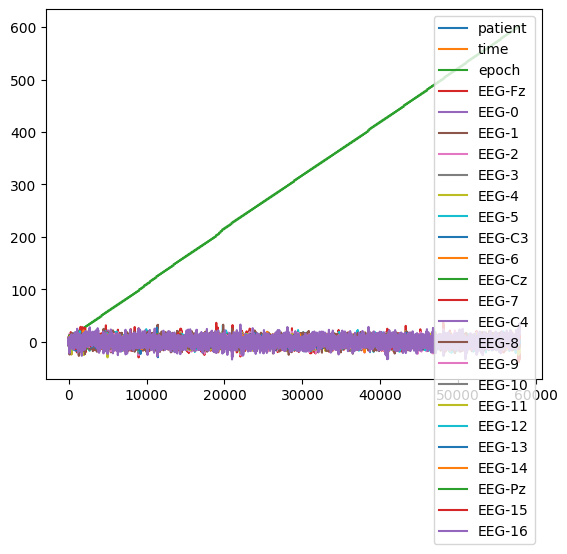

In [ ]:
df.plot()

In [ ]:
import numpy as np
from scipy.signal import welch
from scipy.stats import skew, kurtosis
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define sampling frequency from previous cells
FS = 250.0 # From Q7mKOHIS9cFM or 9l2p1fwr8ot-

# Assuming seizurestart and seizureend are time indices, not absolute times within df['time']
# If they are meant to be row indices, use .iloc for slicing
# Given the original usage with tmin/tmax, they are likely times derived from original indices.
# Let's assume they are absolute time values within the 'time' column of df.
seizurestart_time_val = df.loc[df['epoch'] == 8, 'time'].min() + (2996 * (1/FS)) # Approximate based on context
seizureend_time_val = df.loc[df['epoch'] == 8, 'time'].min() + (3036 * (1/FS))

# Extract seizure data using time column filtering
seizure_data_df = df[(df['time'] >= seizurestart_time_val) & (df['time'] <= seizureend_time_val)].copy()
seizure_label = 1

# Extract no seizure data
no_seizure_df1 = df[df['time'] < seizurestart_time_val].copy()
no_seizure_df2 = df[df['time'] > seizureend_time_val].copy()
no_seizure_label = 0

# Combine no seizure data
no_seizure_df = pd.concat([no_seizure_df1, no_seizure_df2])

# Feature calculation functions, modified to work with pandas DataFrames
def calculate_time_domain_features_from_df(dataframe, eeg_channels):
    data = dataframe[eeg_channels].values
    # Ensure data has enough samples for stats, handle empty dataframes
    if data.size == 0:
        # Return default values (e.g., NaNs or zeros) for consistency in concatenation
        num_channels = len(eeg_channels)
        return {
            'mean': np.full(num_channels, np.nan),
            'std_dev': np.full(num_channels, np.nan),
            'variance': np.full(num_channels, np.nan),
            'skewness': np.full(num_channels, np.nan),
            'excess_kurtosis': np.full(num_channels, np.nan)
        }
    return {
        'mean': np.mean(data, axis=0),
        'std_dev': np.std(data, axis=0),
        'variance': np.var(data, axis=0),
        'skewness': skew(data, axis=0) if data.shape[0] > 1 else np.full(data.shape[1], np.nan),
        'excess_kurtosis': kurtosis(data, axis=0) if data.shape[0] > 1 else np.full(data.shape[1], np.nan)
    }

def calculate_frequency_domain_features_from_df(dataframe, sampling_frequency, eeg_channels):
    data = dataframe[eeg_channels].values
    if data.size == 0:
        num_channels = len(eeg_channels)
        return {'alpha_power': np.full(num_channels, np.nan)}

    psd_list = []
    for channel_idx in range(data.shape[1]):
        channel_data = data[:, channel_idx]
        # Ensure nperseg is not larger than segment length
        nperseg_val = min(len(channel_data), 4 * int(sampling_frequency))
        if nperseg_val == 0:
            psd_list.append(np.array([]))
            continue
        freqs, psd = welch(channel_data, sampling_frequency, nperseg=nperseg_val)
        psd_list.append(psd)

    psd_array = np.array(psd_list, dtype=object)

    alpha_band = (8, 12)
    alpha_power = []
    for i, psd_ch in enumerate(psd_array):
        if psd_ch.size > 0:
            idx_alpha = np.logical_and(freqs >= alpha_band[0], freqs <= alpha_band[1])
            # Ensure idx_alpha is not empty before trapping
            if np.any(idx_alpha):
                alpha_power.append(np.trapz(psd_ch[idx_alpha], freqs[idx_alpha]))
            else:
                alpha_power.append(0.0) # Or np.nan if no alpha band is found
        else:
            alpha_power.append(np.nan)
    return {'alpha_power': np.array(alpha_power)}

# Identify EEG channels (assuming they start with 'EEG-')
eeg_channels = [col for col in df.columns if col.startswith('EEG-')]

# Calculate features for seizure and no-seizure dataframes
seizure_td_features = calculate_time_domain_features_from_df(seizure_data_df, eeg_channels)
seizure_fd_features = calculate_frequency_domain_features_from_df(seizure_data_df, FS, eeg_channels)

seizure_features_dict = {k: v for k, v in seizure_td_features.items()}
seizure_features_dict['alpha_power'] = seizure_fd_features['alpha_power']
seizure_features_dataframe = pd.DataFrame(seizure_features_dict)
seizure_features_dataframe['label'] = seizure_label

no_seizure_td_features = calculate_time_domain_features_from_df(no_seizure_df, eeg_channels)
no_seizure_fd_features = calculate_frequency_domain_features_from_df(no_seizure_df, FS, eeg_channels)

no_seizure_features_dict = {k: v for k, v in no_seizure_td_features.items()}
no_seizure_features_dict['alpha_power'] = no_seizure_fd_features['alpha_power']
no_seizure_features_dataframe = pd.DataFrame(no_seizure_features_dict)
no_seizure_features_dataframe['label'] = no_seizure_label

combined_features_dataframe = pd.concat([seizure_features_dataframe, no_seizure_features_dataframe], ignore_index=True)

# Drop rows with NaN values that might result from empty data or insufficient samples for feature calculation
combined_features_dataframe.dropna(inplace=True)

X = combined_features_dataframe.drop('label', axis=1)
y = combined_features_dataframe['label']

# Ensure there's enough data to split after dropping NaNs
if len(X) > 0:
    X_train_cnn, X_temp_cnn, y_train_cnn, y_temp_cnn = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_val_cnn, X_test_cnn, y_val_cnn, y_test_cnn = train_test_split(X_temp_cnn, y_temp_cnn, test_size=0.5, random_state=42, stratify=y_temp_cnn)

    # Reshape for Conv1D
    input_shape_cnn = (X_train_cnn.shape[1], 1)
    X_train_cnn_reshaped = X_train_cnn.values.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
    X_val_cnn_reshaped = X_val_cnn.values.reshape(X_val_cnn.shape[0], X_val_cnn.shape[1], 1)
    X_test_cnn_reshaped = X_test_cnn.values.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

    def build_cnn_1d_binary(input_shape):
        model = Sequential()
        model.add(Conv1D(32, 2, activation='relu', input_shape=input_shape))
        model.add(Dropout(0.25))
        model.add(Conv1D(64, 2, activation='relu'))
        model.add(MaxPooling1D(1))
        model.add(Dropout(0.25))
        model.add(Flatten())
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(0.5))
        model.add(Dense(1, activation='sigmoid'))
        return model

    model_cnn = build_cnn_1d_binary(input_shape_cnn)
    model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history_cnn = model_cnn.fit(X_train_cnn_reshaped, y_train_cnn, epochs=50, validation_data=(X_val_cnn_reshaped, y_val_cnn))
else:
    print("Not enough data to create features for CNN after filtering.")

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8824 - loss: 0.6801 - val_accuracy: 1.0000 - val_loss: 0.1649
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7647 - loss: 0.5760 - val_accuracy: 1.0000 - val_loss: 0.0889
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9412 - loss: 0.1217 - val_accuracy: 1.0000 - val_loss: 0.0499
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.0299 - val_accuracy: 1.0000 - val_loss: 0.0305
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.0450 - val_accuracy: 1.0000 - val_loss: 0.0200
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.0138
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 0.0100
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0076
E

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_val_pred = model_cnn.predict(X_val_cnn_reshaped)
y_val_pred = (y_val_pred > 0.5).astype(int)

accuracy = accuracy_score(y_val_cnn, y_val_pred)
precision = precision_score(y_val_cnn, y_val_pred)
recall = recall_score(y_val_cnn, y_val_pred)
f1 = f1_score(y_val_cnn, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
